In [1]:
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt 

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# FIRST 7 QUESTIONS

## 1. How big is the data 

In [4]:
df.shape

(918, 12)

## 2. How does the data look like 

In [5]:
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
845,61,F,ASY,145,307,0,LVH,146,Y,1.0,Flat,1
635,67,M,ASY,120,229,0,LVH,129,Y,2.6,Flat,1
557,56,M,NAP,137,208,1,ST,122,Y,1.8,Flat,1
634,40,M,TA,140,199,0,Normal,178,Y,1.4,Up,0
631,46,M,ASY,140,311,0,Normal,120,Y,1.8,Flat,1


## 3. What is the datatype of columns 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## 4. Are there any missing values 

In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## 5. How does the data look mathematically 

In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## 6. Are there any duplicate values 

In [10]:
df.duplicated().sum()

np.int64(0)

## 7. How is the correlation between columns 

In [12]:
df.corr(numeric_only = True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


# EDA

In [14]:
# Numeric - Age, RestingBP , Cholesterol , MaxHR , Oldpeak 
# Categorical - Sex , ChestPainType , RestingECG , ExcerciseAngina , ST_Slope , HeartDisease , FastingBS

# Univariate analysis 

## Numeric columns

### 1. Age
- Almost normal distribution
- Mean age = 54
- No Outliers
- No null values

<Axes: ylabel='Frequency'>

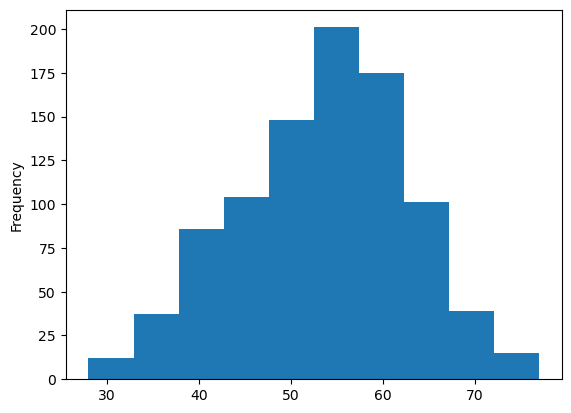

In [15]:
df["Age"].plot(kind = "hist")

<Axes: ylabel='Density'>

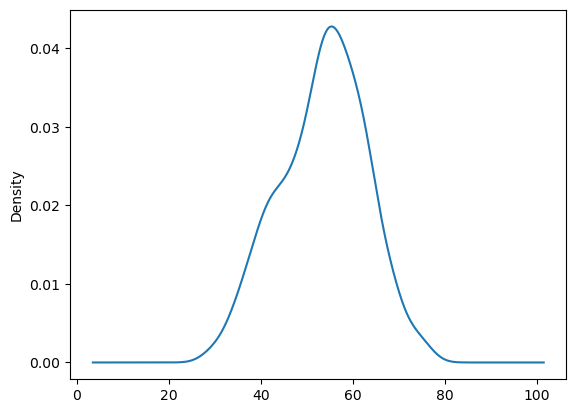

In [16]:
df["Age"].plot(kind = "kde")

In [17]:
df["Age"].skew()

np.float64(-0.19593302867569365)

<Axes: >

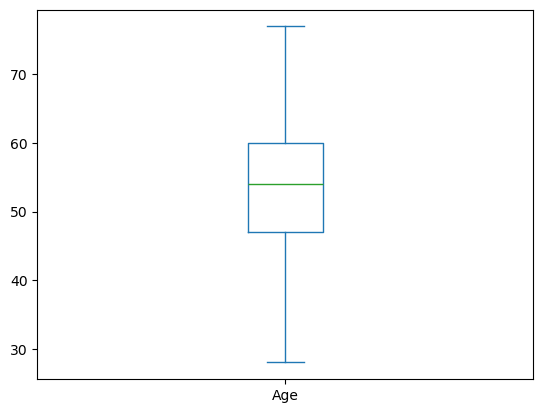

In [18]:
df["Age"].plot(kind = "box")

In [19]:
df["Age"].describe()

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

### 2. RestingBP
- Almost normal distribution (A little left skewed)
- Mean = 133
- Many outliers
- No null values

<Axes: ylabel='Frequency'>

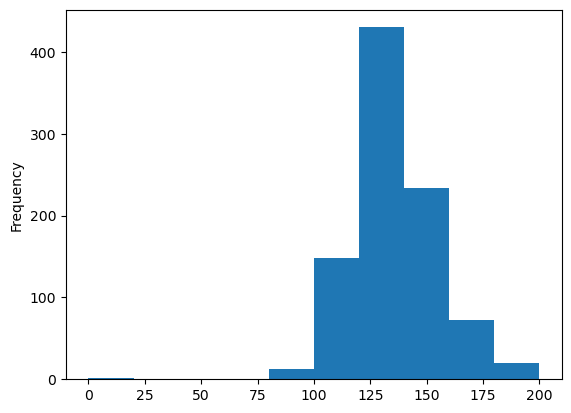

In [20]:
df["RestingBP"].plot(kind = "hist")

<Axes: ylabel='Density'>

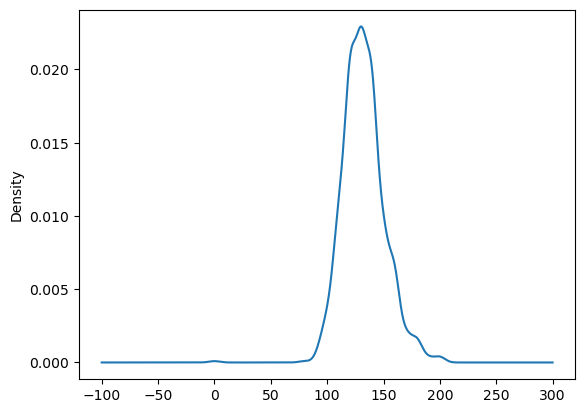

In [21]:
df["RestingBP"].plot(kind = "kde")

In [22]:
df["RestingBP"].skew()

np.float64(0.1798393100516288)

<Axes: >

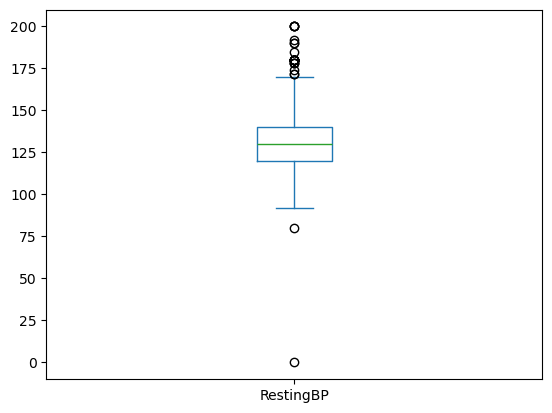

In [51]:
df["RestingBP"].plot(kind = "box")

In [24]:
df["RestingBP"].describe()

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

### 3. Cholesterol
- Bimodal Distribution
- Peak at 0 and 199
- Many Outliers
- No null values

<Axes: ylabel='Frequency'>

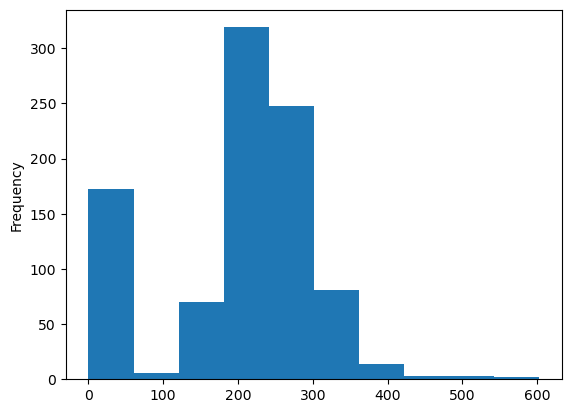

In [25]:
df["Cholesterol"].plot(kind = "hist")

<Axes: ylabel='Density'>

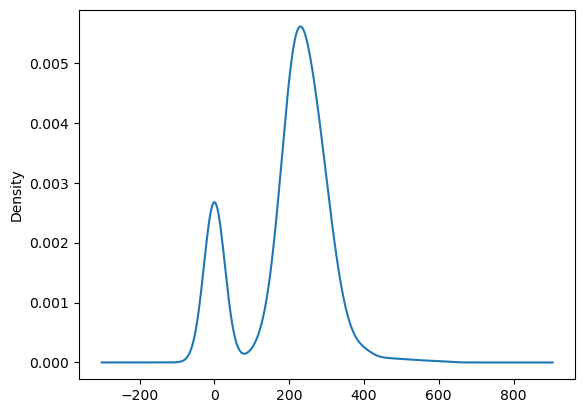

In [26]:
df["Cholesterol"].plot(kind = "kde")

<Axes: >

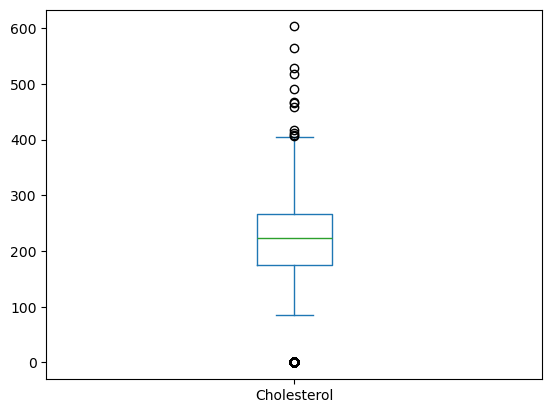

In [50]:
df["Cholesterol"].plot(kind = "box")

In [34]:
df["Cholesterol"].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

### 4. MaxHR
- Bimodal distribution with very close peaks
- No outliers
- No null values 

<Axes: ylabel='Frequency'>

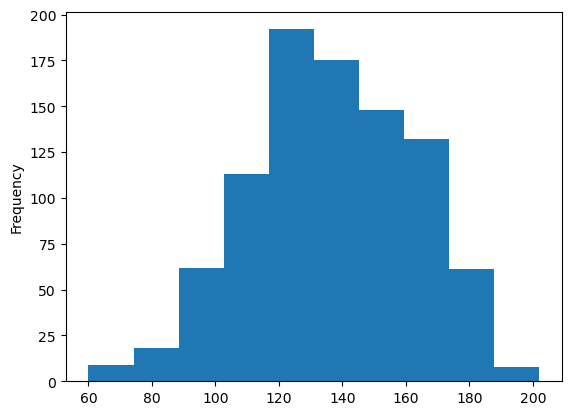

In [35]:
df["MaxHR"].plot(kind = "hist")

<Axes: ylabel='Density'>

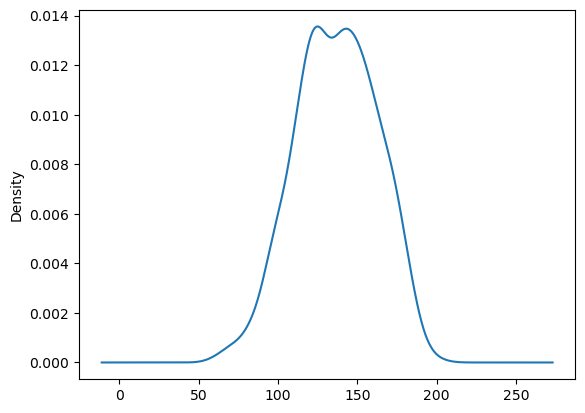

In [36]:
df["MaxHR"].plot(kind = "kde")

<Axes: >

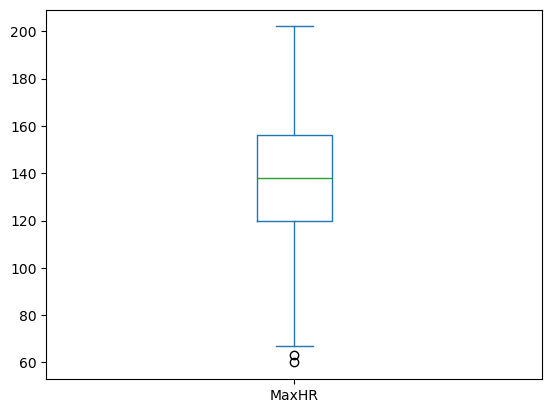

In [40]:
df["MaxHR"].plot(kind = "box")

In [41]:
df["MaxHR"].describe()

count    918.000000
mean     136.809368
std       25.460334
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: MaxHR, dtype: float64

In [42]:
iqr = df["MaxHR"].quantile(.75) - df["MaxHR"].quantile(.25)
q3 = df["MaxHR"].quantile(.75)
q1 = df["MaxHR"].quantile(.25)

In [45]:
df[df["MaxHR"] < q1 - 1.5 * iqr]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
370,60,M,ASY,135,0,0,Normal,63,Y,0.5,Up,1
390,51,M,ASY,140,0,0,Normal,60,N,0.0,Flat,1


In [48]:
df = df.drop(index = [370 , 390])

<Axes: >

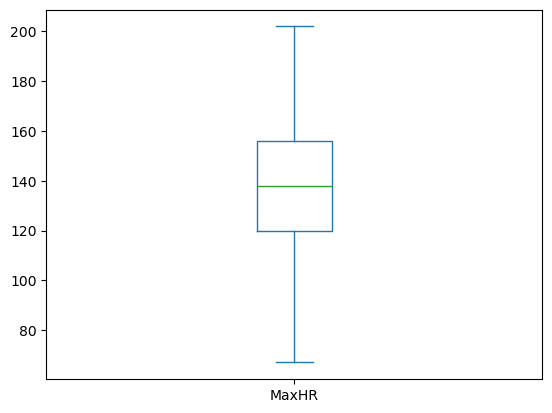

In [49]:
df["MaxHR"].plot(kind = "box")

In [53]:
# Numeric - Age, RestingBP , Cholesterol , MaxHR , Oldpeak 
# Categorical - Sex , ChestPainType , RestingECG , ExcerciseAngina , ST_Slope , HeartDisease , FastingBS

### 5. Oldpeak
- Random distribution
- Multiple outliers
- No null values

<Axes: ylabel='Frequency'>

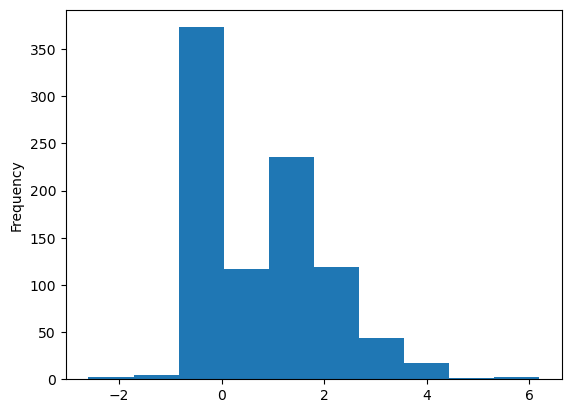

In [54]:
df["Oldpeak"].plot(kind = "hist")

<Axes: ylabel='Density'>

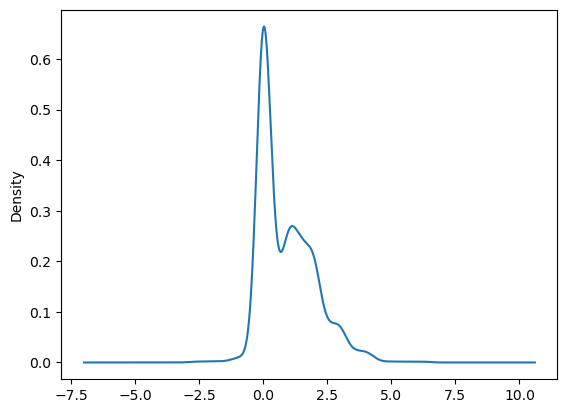

In [55]:
df["Oldpeak"].plot(kind = "kde")

<Axes: >

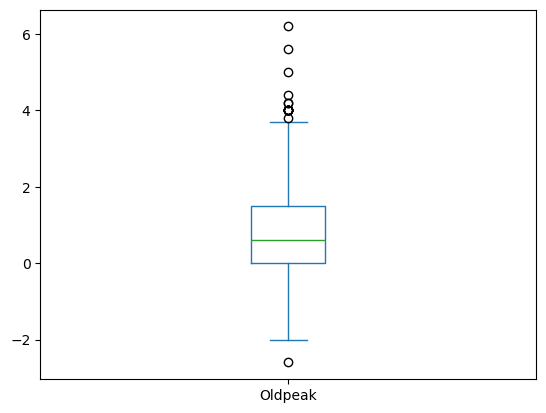

In [56]:
df["Oldpeak"].plot(kind = "box")

In [57]:
df["Oldpeak"].describe()

count    916.000000
mean       0.888755
std        1.067254
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

## 2. Categorical Data

In [73]:
# Categorical - Sex , ChestPainType , RestingECG , ExerciseAngina , ST_Slope , HeartDisease , FastingBS

### 1. Sex 
- There are 79 percent Men and 21 percent Women

<Axes: xlabel='count', ylabel='Sex'>

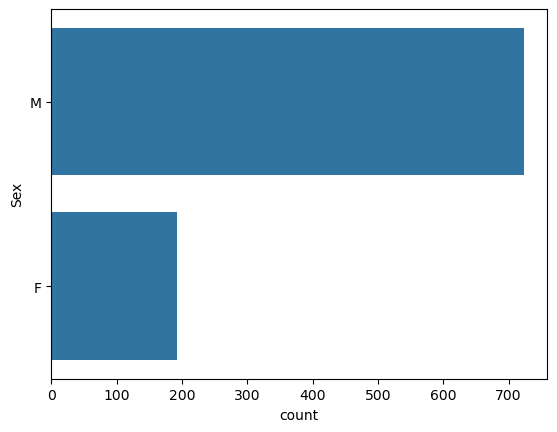

In [59]:
sns.countplot(df["Sex"])

In [65]:
df["Sex"].value_counts()

Sex
M    723
F    193
Name: count, dtype: int64

<Axes: ylabel='count'>

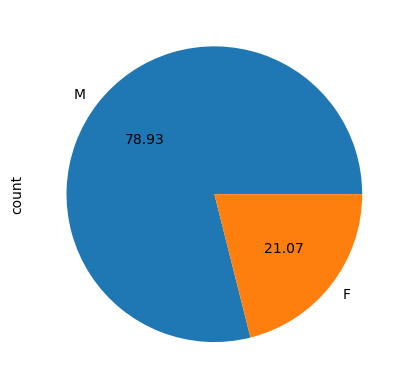

In [60]:
df["Sex"].value_counts().plot(kind = "pie",autopct = "%.2f")

### 2. ChestPainType
- Pain with max people is ASY with 54 percent of total people
- Pain with least people is TA with 5 percent of total people 

<Axes: xlabel='count', ylabel='ChestPainType'>

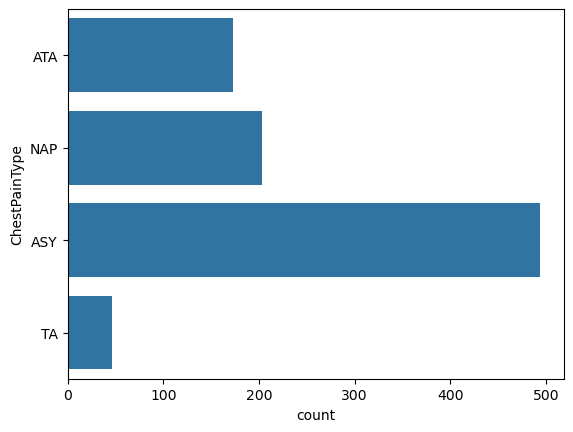

In [62]:
sns.countplot(df["ChestPainType"])

In [63]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    494
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

<Axes: ylabel='count'>

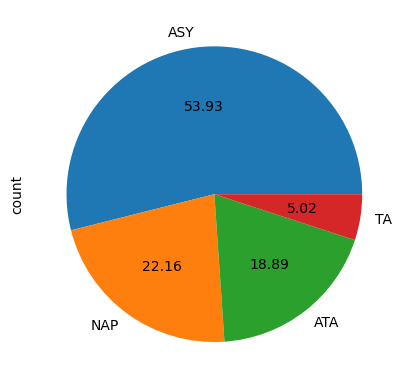

In [64]:
df["ChestPainType"].value_counts().plot(kind = "pie" , autopct = "%.2f")

### 3. RestingECG
- 60 percent of people have normal restingECG 
- ST and LVH share almost equal percentages of people i.e 20 percent

<Axes: xlabel='count', ylabel='RestingECG'>

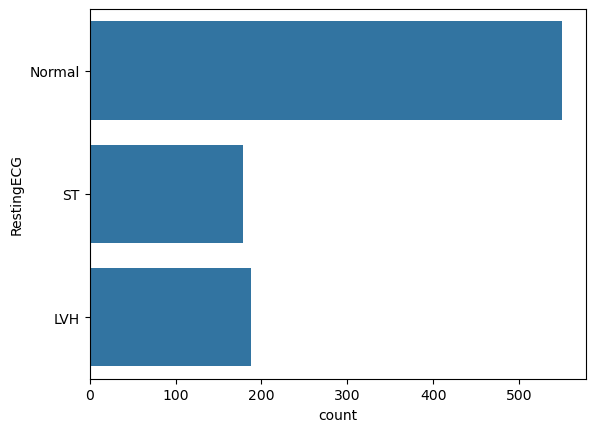

In [67]:
sns.countplot(df["RestingECG"])

In [68]:
df["RestingECG"].value_counts()

RestingECG
Normal    550
LVH       188
ST        178
Name: count, dtype: int64

<Axes: ylabel='count'>

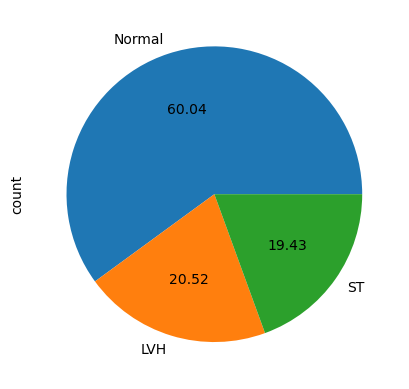

In [69]:
df["RestingECG"].value_counts().plot(kind = "pie",autopct = "%.2f")

### 4. ExerciseAngina
- it means exercise-induced pain
- 40 percent of people experience ExerciseAngina
- Rest 60 percent don't 

<Axes: xlabel='count', ylabel='ExerciseAngina'>

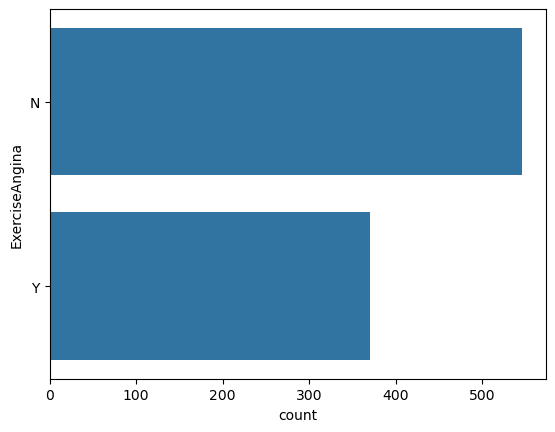

In [74]:
sns.countplot(df["ExerciseAngina"])

In [76]:
df["ExerciseAngina"].value_counts()

ExerciseAngina
N    546
Y    370
Name: count, dtype: int64

<Axes: ylabel='count'>

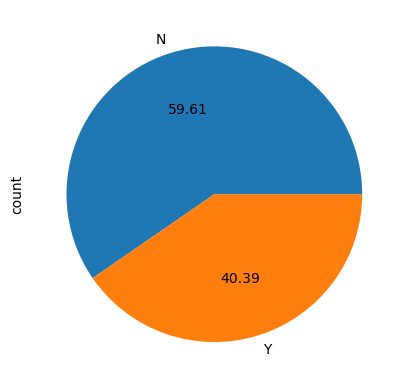

In [77]:
df["ExerciseAngina"].value_counts().plot(kind = "pie",autopct = "%.2f")

### 5. ST_Slope
- ST_Slope is typically categorized into three values: 
- Upsloping: Considered less likely to indicate heart disease and often a normal, benign response.
- Horizontal: Associated with a worse outcome and a higher risk of heart disease compared to an upsloping or downsloping ST segment.
- Downsloping: A strong indicator of potential myocardial ischemia and highly predictive of heart disease.


- 50 percent of people have horizontal slope
- 43 percent have upslope and 7 percent have downslope

<Axes: xlabel='count', ylabel='ST_Slope'>

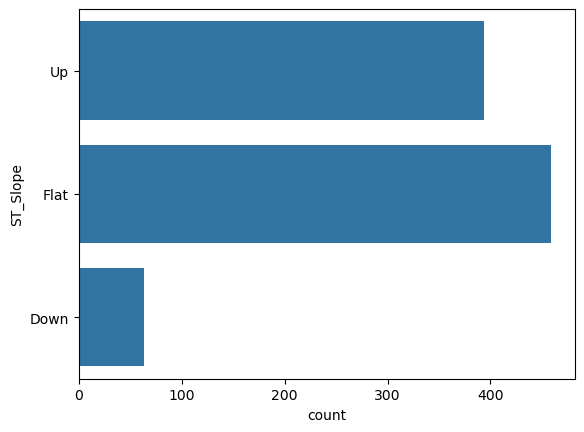

In [79]:
sns.countplot(df["ST_Slope"])

In [80]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    459
Up      394
Down     63
Name: count, dtype: int64

<Axes: ylabel='count'>

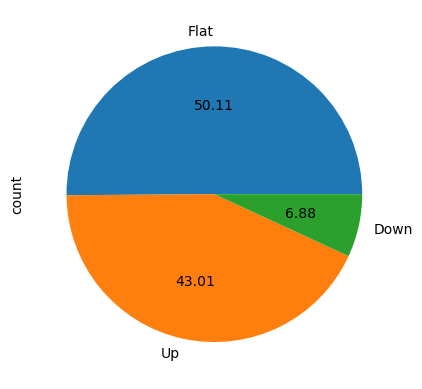

In [81]:
df["ST_Slope"].value_counts().plot(kind = "pie",autopct = "%.2f")

### 6. HeartDisease
- Atlast 56 percent people were detected with a heart disease and rest 44 percent weren't 

In [86]:
df["HeartDisease"].value_counts()

HeartDisease
1    506
0    410
Name: count, dtype: int64

<Axes: ylabel='count'>

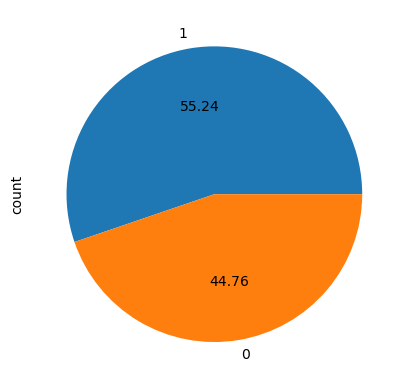

In [87]:
df["HeartDisease"].value_counts().plot(kind = "pie" , autopct = "%.2f")

### 7. FastingBS
-  fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- 77 percent don't have FastingBS > 120 
- rest 23 percent have 

In [90]:
df["FastingBS"].value_counts()

FastingBS
0    702
1    214
Name: count, dtype: int64

<Axes: ylabel='count'>

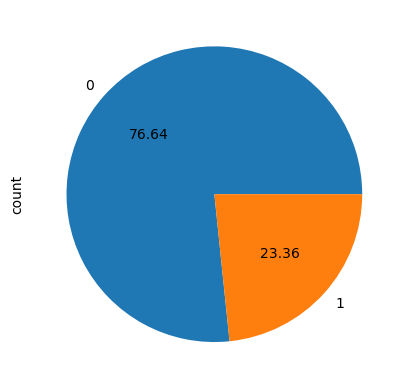

In [91]:
df["FastingBS"].value_counts().plot(kind = "pie",autopct = "%.2f")

# Bivariate and Multivariate Analysis 

##  Numerical - Numerical 

In [92]:
# Numeric - Age, RestingBP , Cholesterol , MaxHR , Oldpeak 
# Categorical - Sex , ChestPainType , RestingECG , ExcerciseAngina , ST_Slope , HeartDisease , FastingBS

### 1. Age and RestingBP
- RestingBP increases generally as age increases 

<Axes: xlabel='Age', ylabel='RestingBP'>

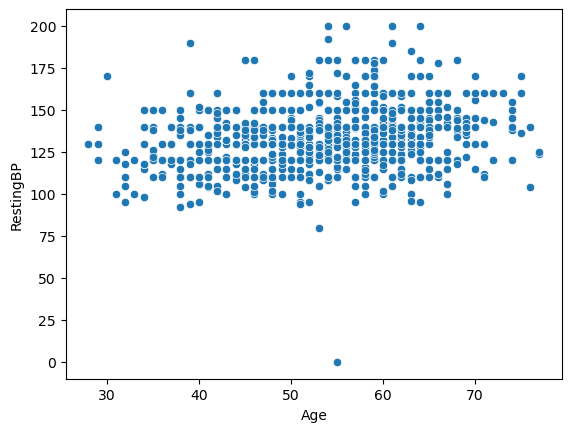

In [96]:
sns.scatterplot(x = "Age",y = "RestingBP" , data = df)

<Axes: xlabel='Age', ylabel='RestingBP'>

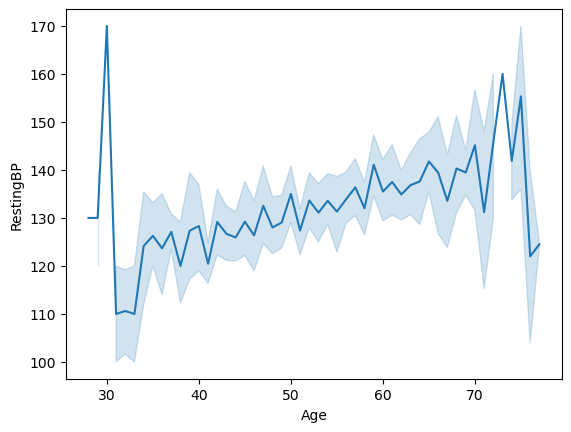

In [97]:
sns.lineplot(x = "Age" , y = "RestingBP" , data = df)

### 2. Age and Cholesterol 
- Cholesterol slightly decreases with age 

<Axes: xlabel='Age', ylabel='Cholesterol'>

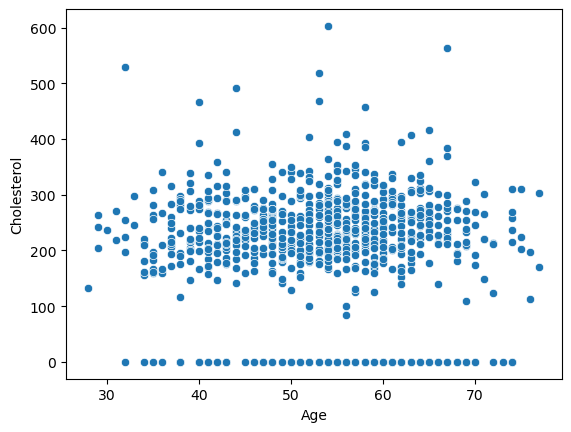

In [99]:
sns.scatterplot(x = "Age" , y = "Cholesterol" , data = df)

<Axes: xlabel='Age', ylabel='Cholesterol'>

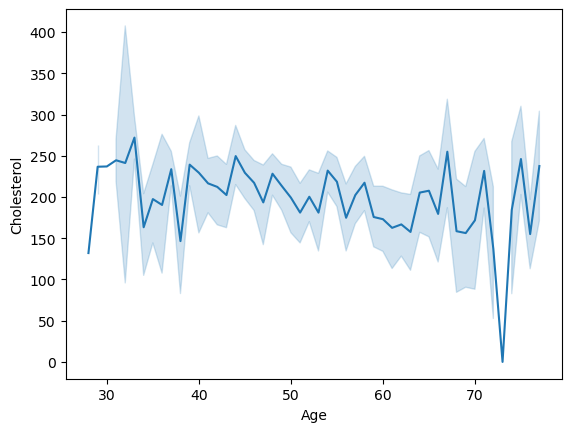

In [100]:
sns.lineplot(x = "Age" , y = "Cholesterol" , data = df)

### 3. Age and MaxHR
- Max Heart Rate decreases with Age 

<Axes: xlabel='Age', ylabel='MaxHR'>

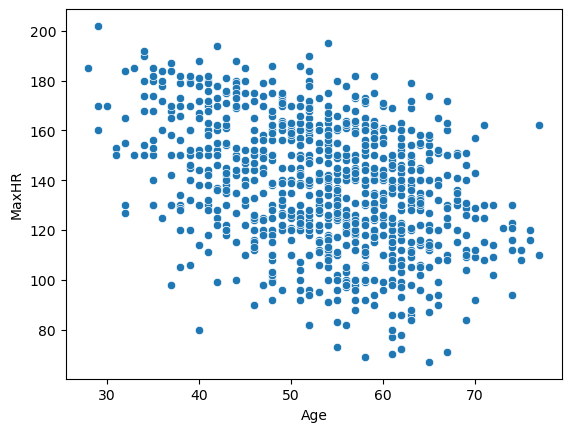

In [102]:
sns.scatterplot(x = "Age" , y = "MaxHR" , data = df)

<Axes: xlabel='Age', ylabel='MaxHR'>

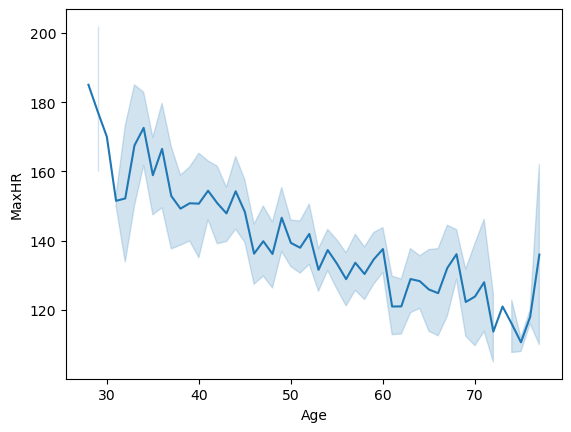

In [103]:
sns.lineplot(x = "Age" , y = "MaxHR" , data = df)

### 4. Age and Oldpeak
- Oldpeak generally increases with Age with some abnormalities after age 70

<Axes: xlabel='Age', ylabel='Oldpeak'>

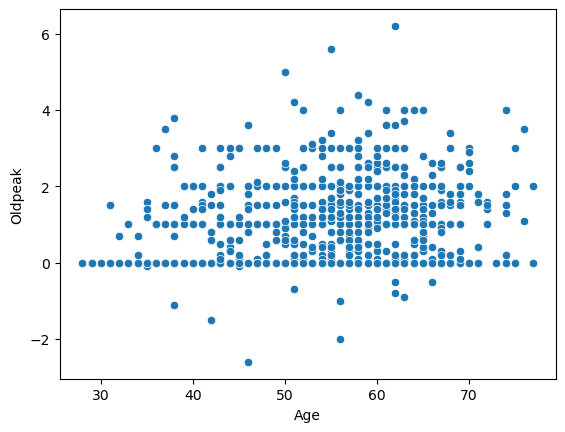

In [106]:
sns.scatterplot(x = "Age" , y = "Oldpeak" , data = df)

<Axes: xlabel='Age', ylabel='Oldpeak'>

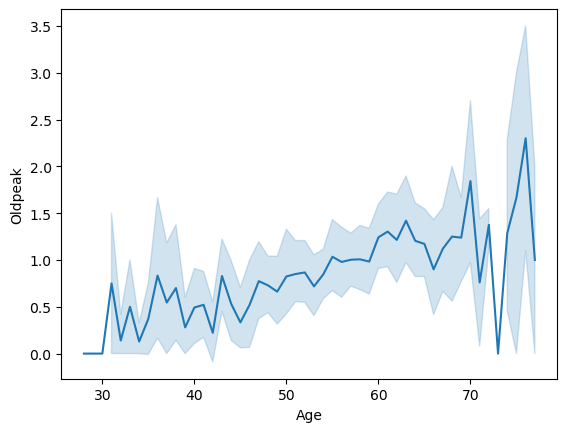

In [107]:
sns.lineplot(x = "Age" , y = "Oldpeak" , data = df)

### 5. RestingBP and Cholesterol 
- Most people have Cholesterol between 150 and 300 and resting bp between 110 and 160 

<Axes: xlabel='RestingBP', ylabel='Cholesterol'>

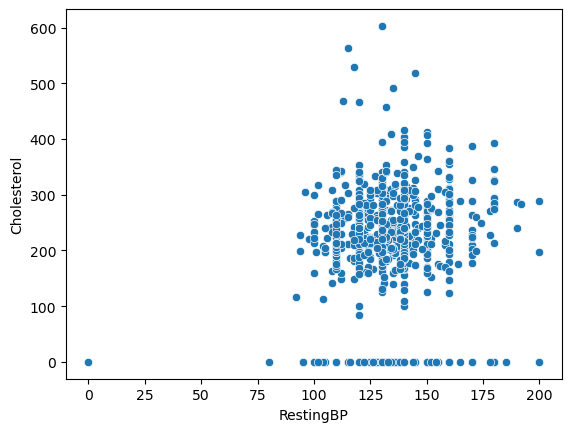

In [109]:
sns.scatterplot(x = "RestingBP" , y = "Cholesterol" , data = df)

### 6. RestingBP and MaxHR

<Axes: xlabel='RestingBP', ylabel='MaxHR'>

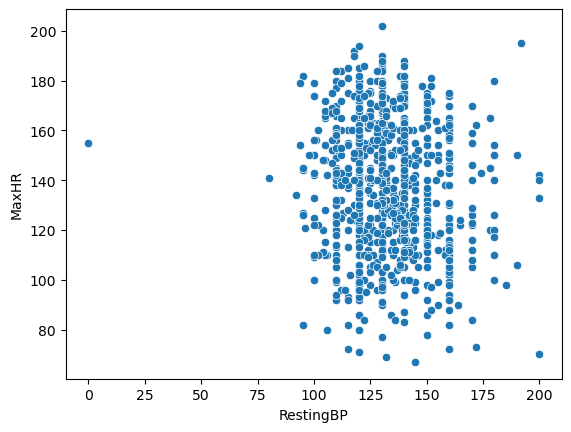

In [112]:
sns.scatterplot(x = "RestingBP" , y = "MaxHR" , data = df)

### 7. RestingBP and Oldpeak

<Axes: xlabel='RestingBP', ylabel='Oldpeak'>

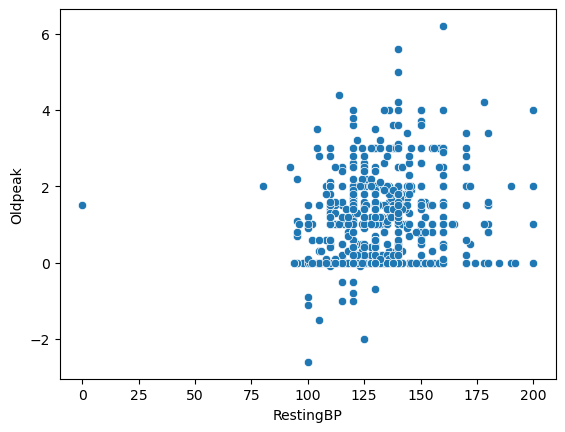

In [114]:
sns.scatterplot(x = "RestingBP" , y = "Oldpeak" , data = df)

In [115]:
# Numeric - Age, RestingBP , Cholesterol , MaxHR , Oldpeak 

### 8. Cholesterol and MaxHR

<Axes: xlabel='RestingBP', ylabel='MaxHR'>

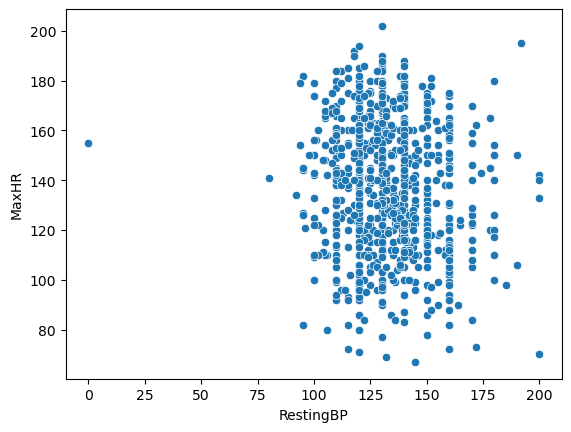

In [117]:
sns.scatterplot(x = "RestingBP" , y = "MaxHR" , data = df)

### 9. Cholesterol and Oldpeak

<Axes: xlabel='Cholesterol', ylabel='Oldpeak'>

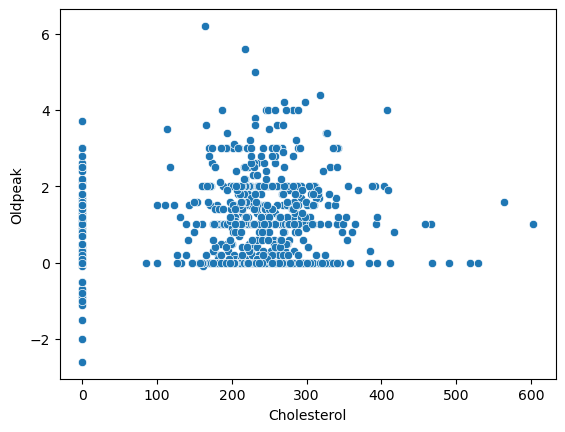

In [119]:
sns.scatterplot(x = "Cholesterol" , y = "Oldpeak" , data = df)

### 10. MaxHR and Oldpeak

<Axes: xlabel='MaxHR', ylabel='Oldpeak'>

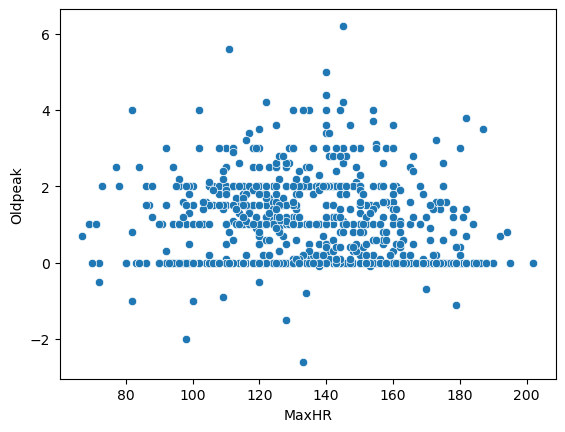

In [120]:
sns.scatterplot(x = "MaxHR" , y = "Oldpeak" , data = df)

## 2. Categorical- Categorical 

In [ ]:
# Categorical - Sex , ChestPainType , RestingECG , ExcerciseAngina , ST_Slope , HeartDisease , FastingBS

### 1. Sex vs ChestPainType
- irrespective of Chest Pain type, men experience more Chest pain as compared to women 

In [129]:
pd.crosstab(df["Sex"] , df["ChestPainType"])

ChestPainType,ASY,ATA,NAP,TA
Sex,,,,
F,70,60,53,10
M,424,113,150,36


<Axes: xlabel='ChestPainType', ylabel='Sex'>

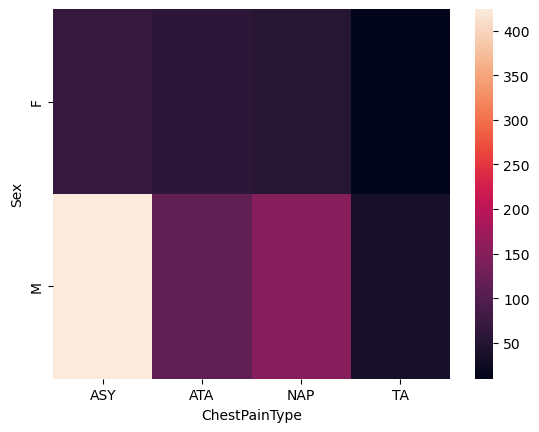

In [130]:
sns.heatmap(pd.crosstab(df["Sex"] , df["ChestPainType"]))

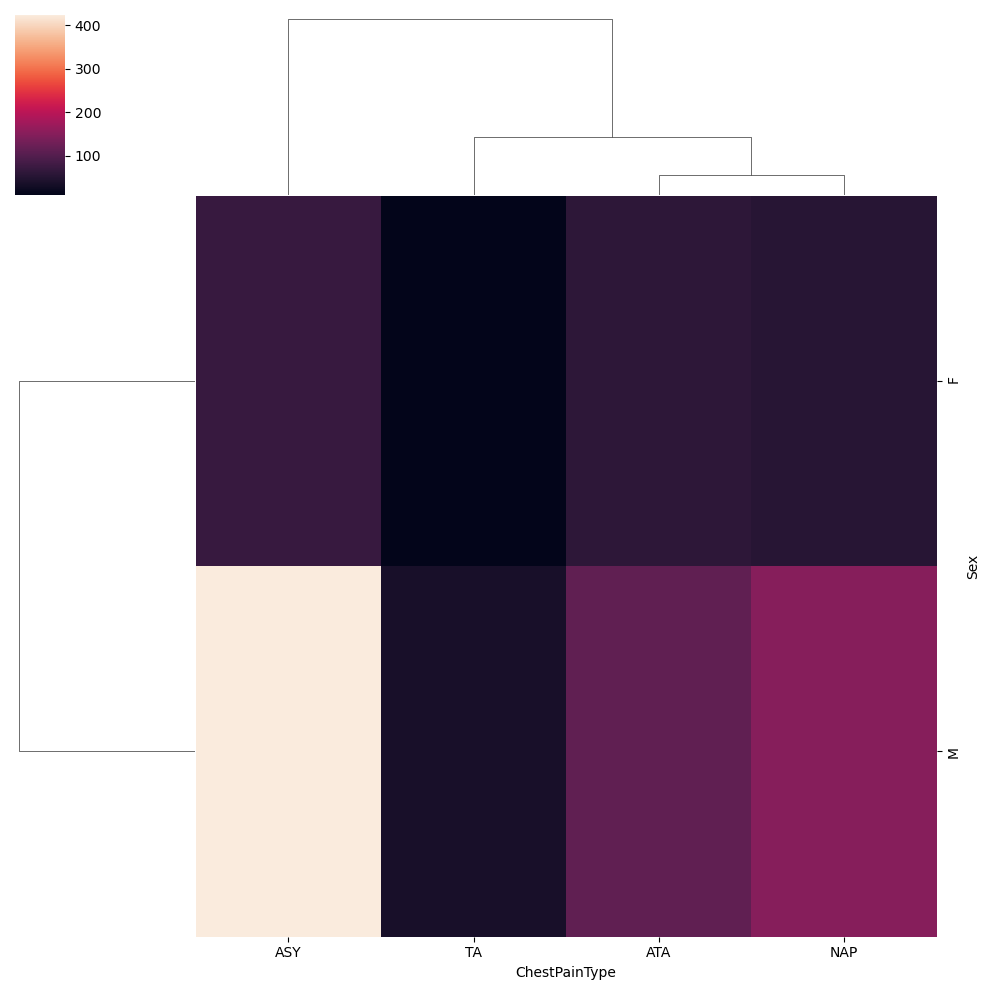

In [134]:
sns.clustermap(pd.crosstab(df["Sex"] , df["ChestPainType"]))

### 2. Sex vs RestingECG
- irrespective of type of Resting ECG, men have higher values than women

In [138]:
pd.crosstab(df["Sex"] , df["RestingECG"])

RestingECG,LVH,Normal,ST
Sex,,,
F,47,118,28
M,141,432,150


<Axes: xlabel='RestingECG', ylabel='Sex'>

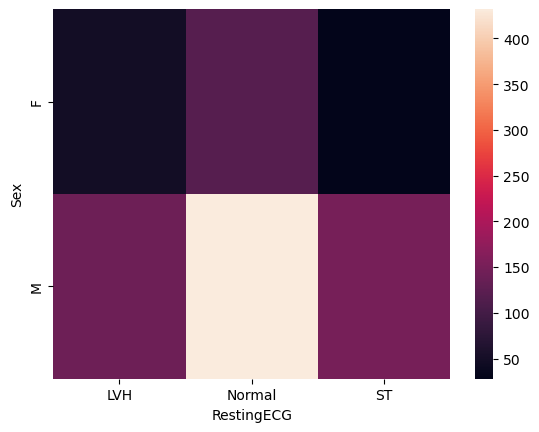

In [135]:
sns.heatmap(pd.crosstab(df["Sex"] , df["RestingECG"]))

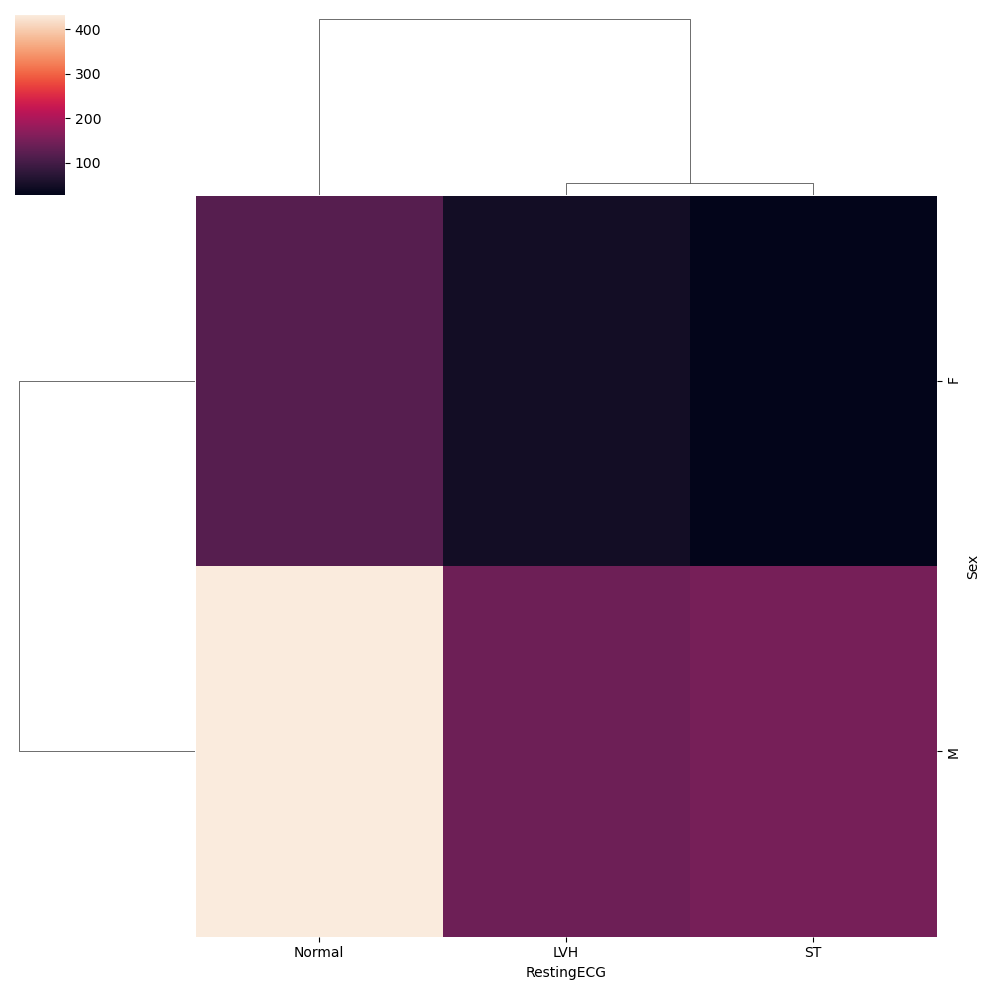

In [136]:
sns.clustermap(pd.crosstab(df["Sex"] , df["RestingECG"]))

### 3. Sex vs ExerciseAngina
- More male suffer with ExerciseAngina as compared to women 

In [144]:
pd.crosstab(df["Sex"] , df["ExerciseAngina"])

ExerciseAngina,N,Y
Sex,,
F,150,43
M,396,327


<Axes: xlabel='ExerciseAngina', ylabel='Sex'>

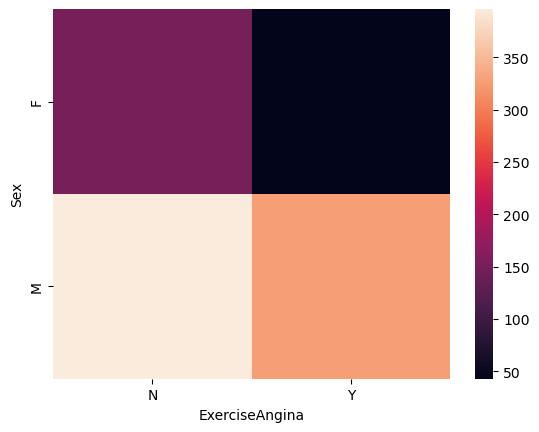

In [142]:
sns.heatmap(pd.crosstab(df["Sex"] , df["ExerciseAngina"]))

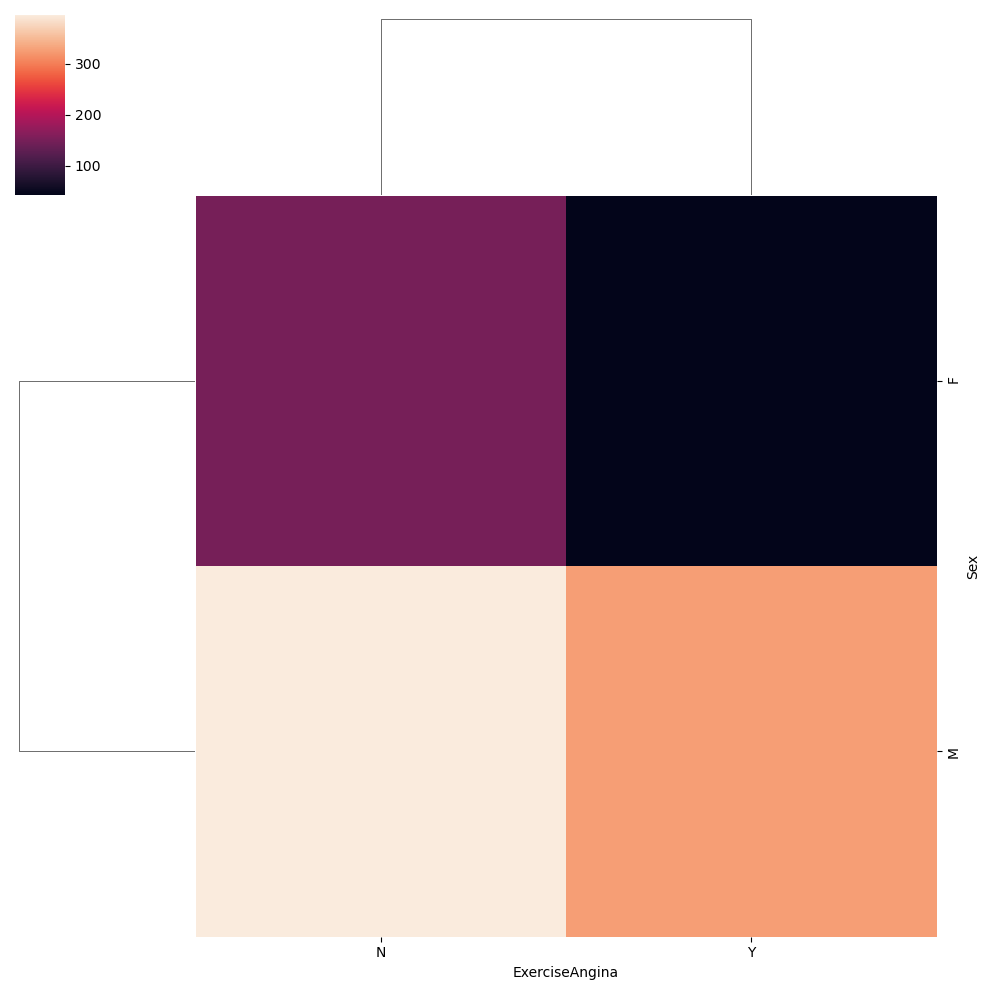

In [143]:
sns.clustermap(pd.crosstab(df["Sex"] , df["ExerciseAngina"]))

### 4. Sex vs ST_Slope

In [146]:
pd.crosstab(df["Sex"] , df["ST_Slope"])

ST_Slope,Down,Flat,Up
Sex,,,
F,7,75,111
M,56,384,283


<Axes: xlabel='ST_Slope', ylabel='Sex'>

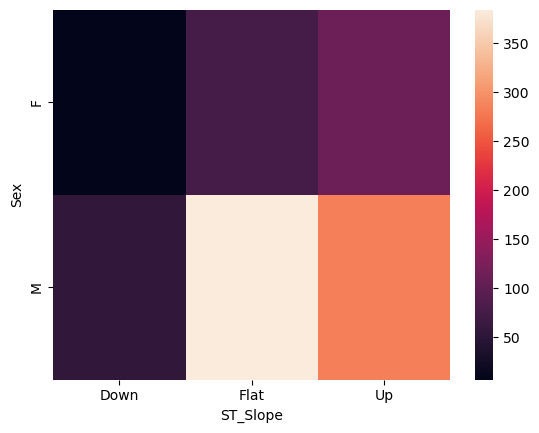

In [152]:
sns.heatmap(pd.crosstab(df["Sex"] , df["ST_Slope"]))

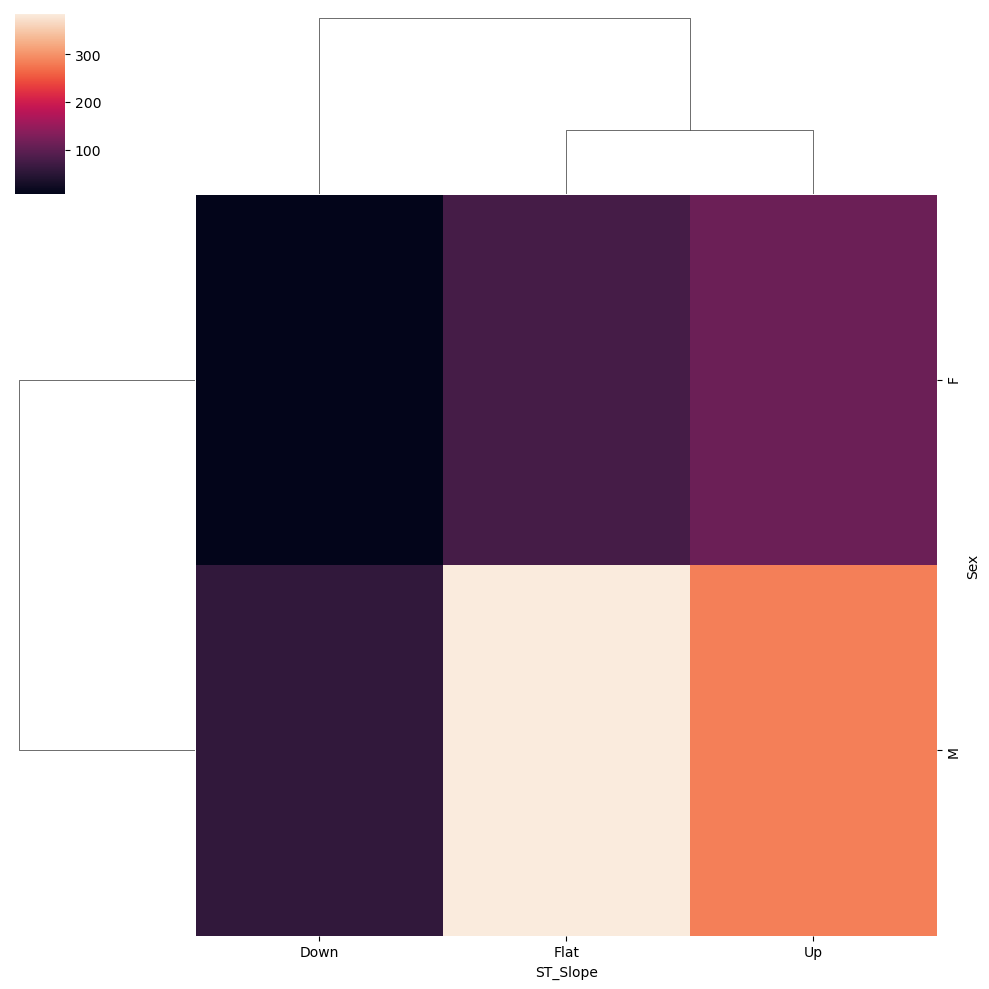

In [145]:
sns.clustermap(pd.crosstab(df["Sex"] , df["ST_Slope"]))

### 5. Sex vs HeartDisease
- generally men suffer more of a heart disease than women 

In [148]:
pd.crosstab(df["Sex"] , df["HeartDisease"])

HeartDisease,0,1
Sex,,
F,143,50
M,267,456


<Axes: xlabel='RestingECG', ylabel='Sex'>

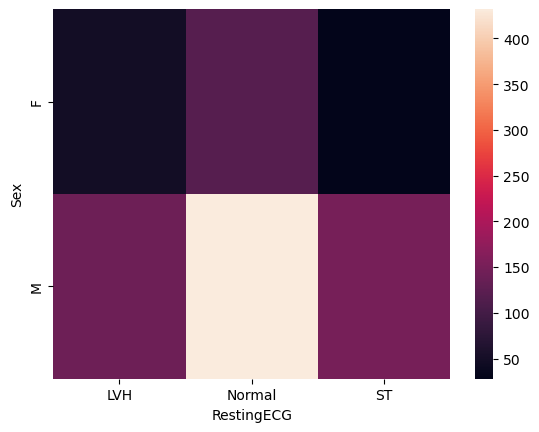

In [153]:
sns.heatmap(pd.crosstab(df["Sex"] , df["RestingECG"]))

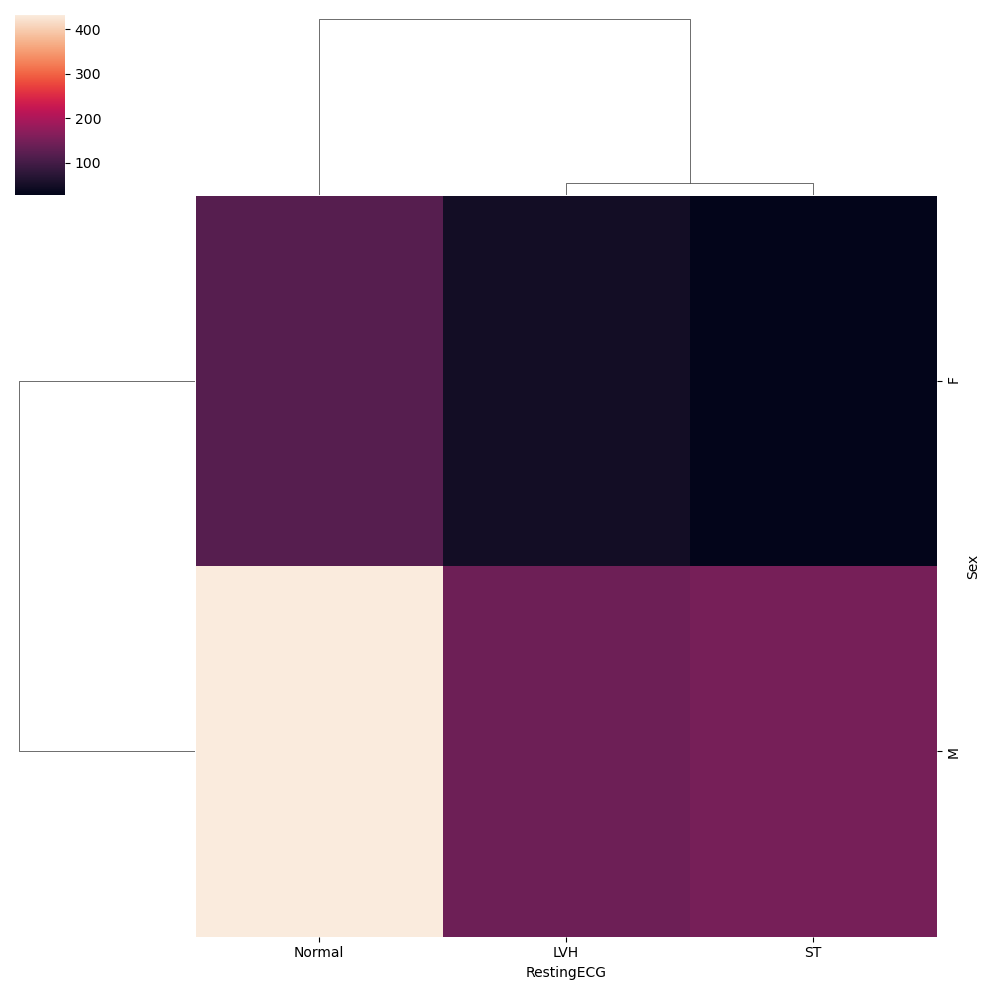

In [151]:
sns.clustermap(pd.crosstab(df["Sex"] , df["RestingECG"]))

### 6. Sex vs FastingBS

### 7. ChestPainType and RestingECG

### 8. ChestPainType and ExcerciseAngina

### 9. ChestPainType and ST_Slope

### 10. ChestPainType and HeartDisease
- People having ASY Chest pain have more likely chances of getting a heart disease
- unlike ATA and NAP 

In [154]:
pd.crosstab(df["ChestPainType"] , df["HeartDisease"])

HeartDisease,0,1
ChestPainType,,
ASY,104,390
ATA,149,24
NAP,131,72
TA,26,20


<Axes: xlabel='HeartDisease', ylabel='ChestPainType'>

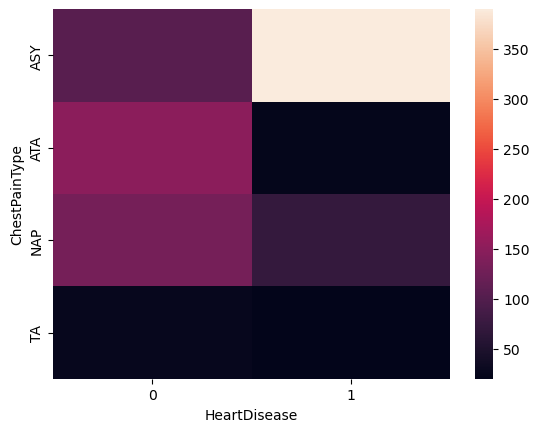

In [156]:
sns.heatmap(pd.crosstab(df["ChestPainType"] , df["HeartDisease"]))

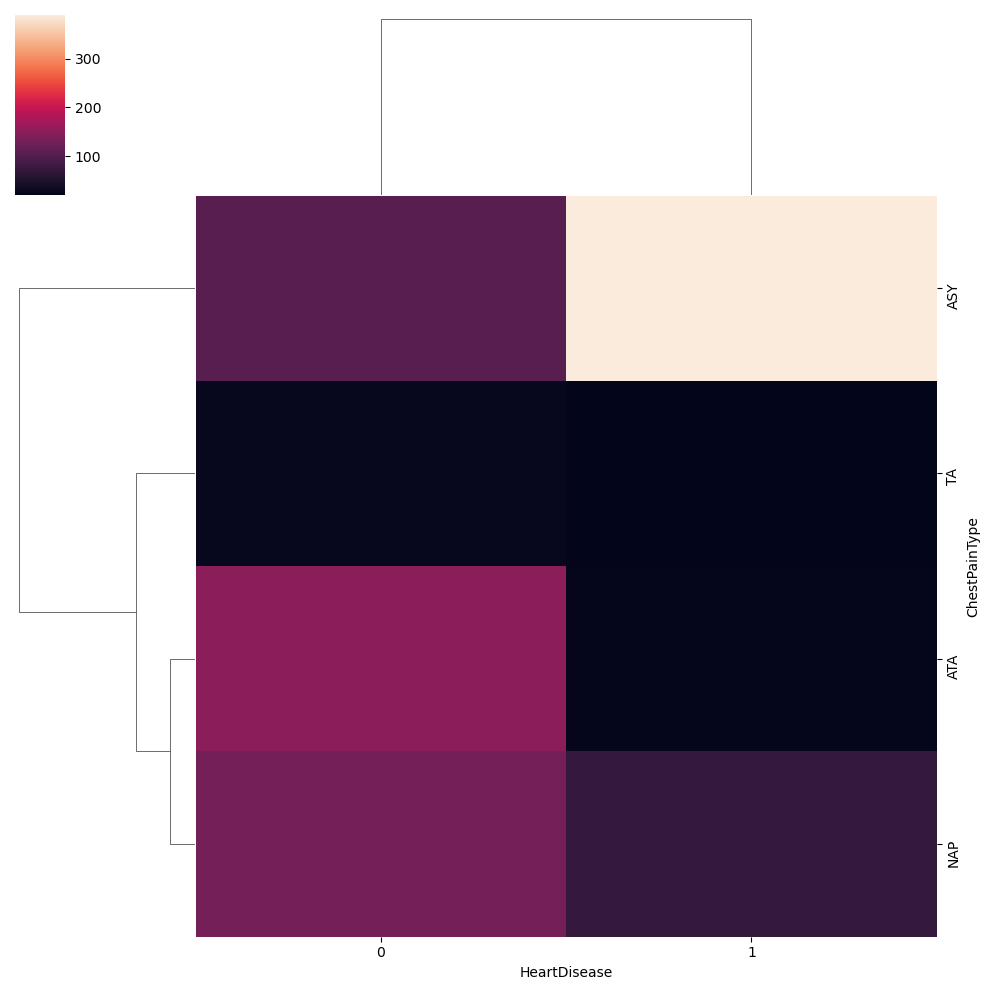

In [155]:
sns.clustermap(pd.crosstab(df["ChestPainType"] , df["HeartDisease"]))

### 11. ChestPainType and FastingBS

### 12. RestingECG and ExcerciseAngina

### 13. RestingECG and ST_Slope

### 14. RestingECG and HeartDisease
- People having LVH and ST are more likely to have a heart disease unlike normal people
- People having normal RestingECG have around 50 percent chance of having heart disease

In [159]:
pd.crosstab(df["RestingECG"] , df["HeartDisease"])

HeartDisease,0,1
RestingECG,,
LVH,82,106
Normal,267,283
ST,61,117


<Axes: xlabel='HeartDisease', ylabel='RestingECG'>

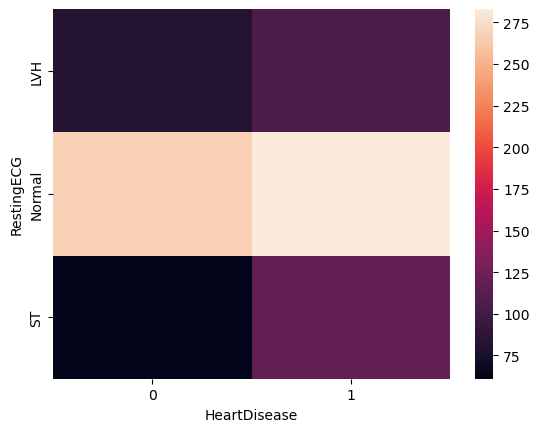

In [158]:
sns.heatmap(pd.crosstab(df["RestingECG"] , df["HeartDisease"]))

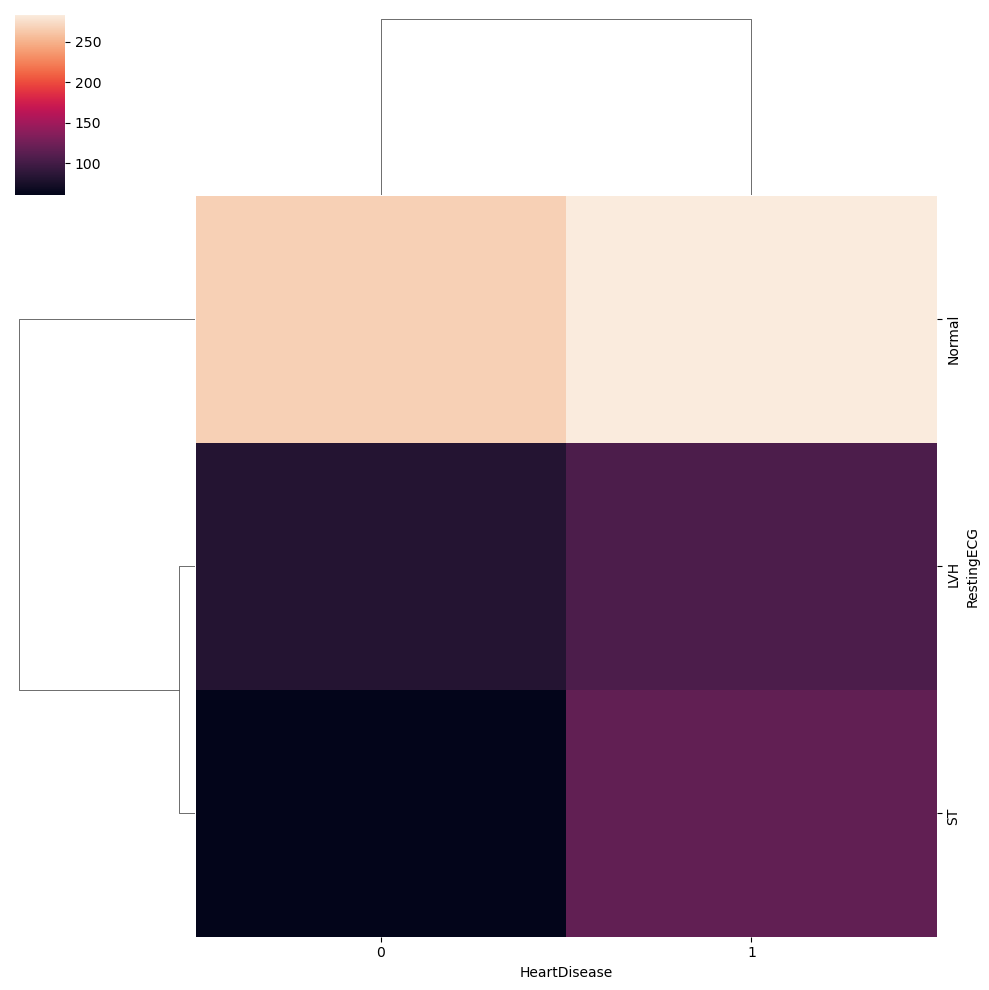

In [157]:
sns.clustermap(pd.crosstab(df["RestingECG"] , df["HeartDisease"]))

### 15. RestingECG and FastingBS

### 16. ExcerciseAngina and ST_Slope

### 17. ExerciseAngina and HeartDisease
- People having Exercise Angina are more likely to have a heart disease 

In [162]:
pd.crosstab(df["ExerciseAngina"] , df["HeartDisease"])

HeartDisease,0,1
ExerciseAngina,,
N,355,191
Y,55,315


<Axes: xlabel='HeartDisease', ylabel='ExerciseAngina'>

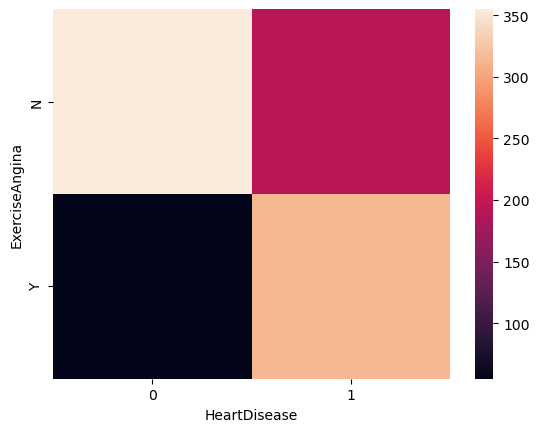

In [163]:
sns.heatmap(pd.crosstab(df["ExerciseAngina"] , df["HeartDisease"]))

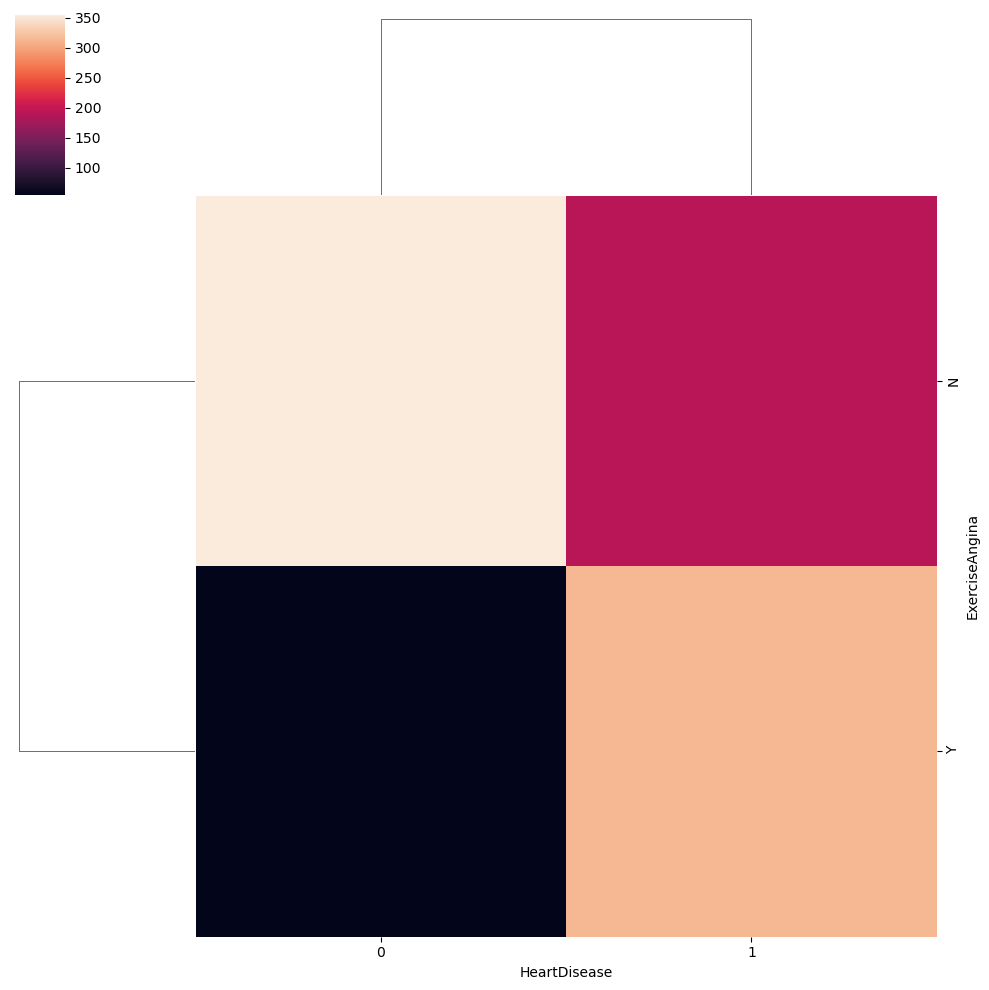

In [161]:
sns.clustermap(pd.crosstab(df["ExerciseAngina"] , df["HeartDisease"]))

### 18. ExcerciseAngina and FastingBS

### 19. ST_Slope and HeartDisease

### 20. ST_Slope and FastingBS

### 21. HeartDisease and FastingBS
- People having blood sugar level > 120  are more likely to get a heart disease 

In [167]:
pd.crosstab(df["FastingBS"] , df["HeartDisease"])

HeartDisease,0,1
FastingBS,,
0,366,336
1,44,170


<Axes: xlabel='HeartDisease', ylabel='FastingBS'>

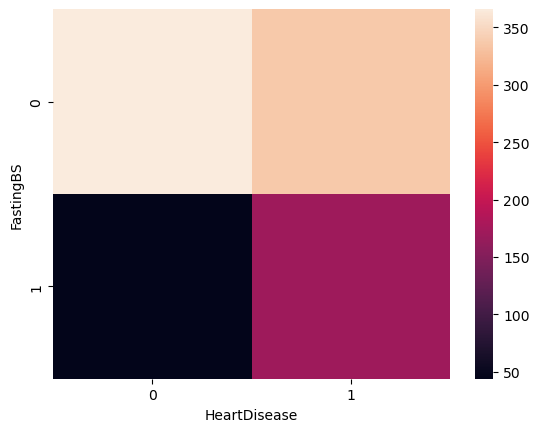

In [165]:
sns.heatmap(pd.crosstab(df["FastingBS"] , df["HeartDisease"]))

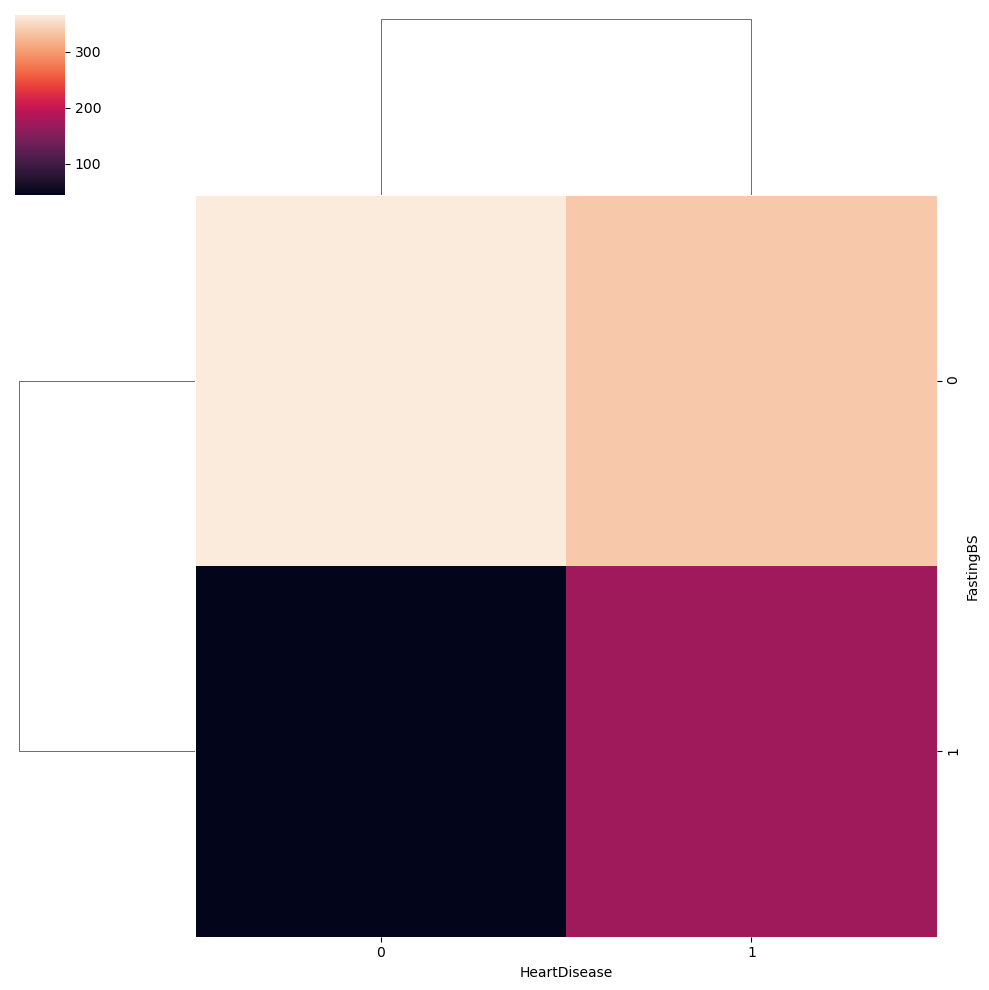

In [166]:
sns.clustermap(pd.crosstab(df["FastingBS"] , df["HeartDisease"]))

## Numerical - Categorical 

In [168]:
# Numeric - Age, RestingBP , Cholesterol , MaxHR , Oldpeak 
# Categorical - Sex , ChestPainType , RestingECG , ExcerciseAngina , ST_Slope , HeartDisease , FastingBS

### 1. Age and HeartDisease 

<Axes: xlabel='HeartDisease', ylabel='Age'>

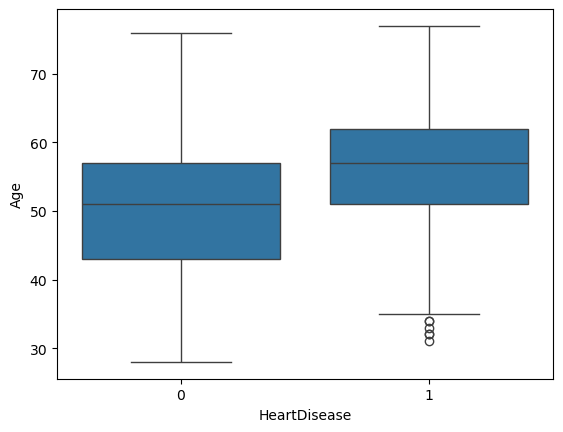

In [171]:
sns.boxplot(y = "Age" , x = "HeartDisease" , data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

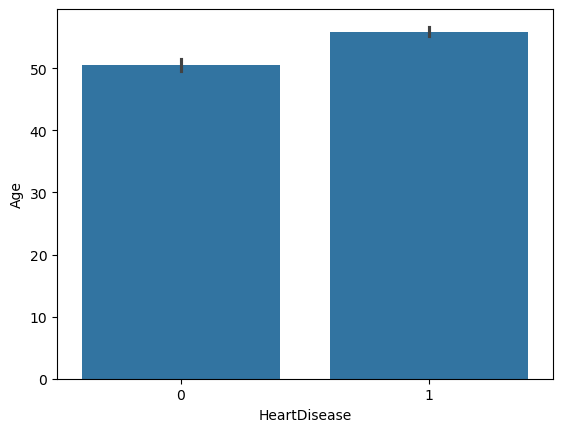

In [174]:
sns.barplot(y = "Age" , x = "HeartDisease" , data = df)

### 2. RestingBP and HeartDisease 

<Axes: xlabel='HeartDisease', ylabel='RestingBP'>

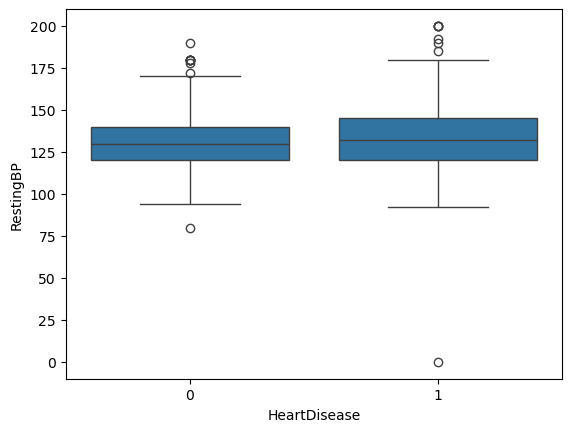

In [175]:
sns.boxplot(y = "RestingBP" , x = "HeartDisease" , data = df)

<Axes: xlabel='HeartDisease', ylabel='RestingBP'>

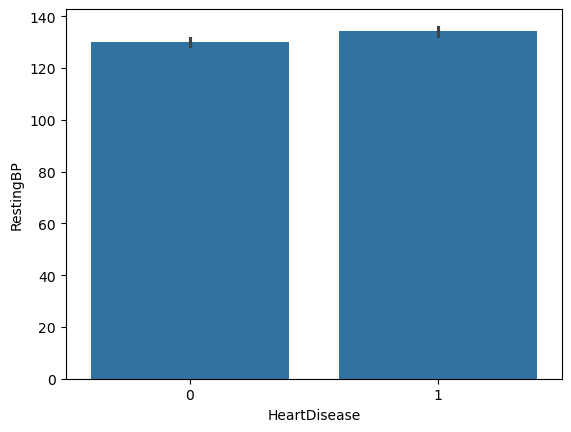

In [176]:
sns.barplot(y = "RestingBP" , x = "HeartDisease" , data = df)

### 3. Cholesterol and HeartDisease 

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

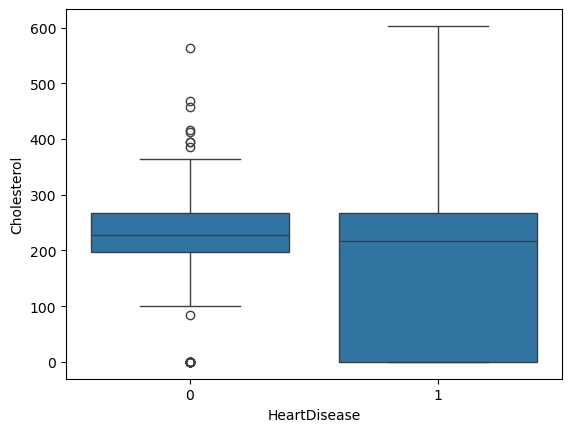

In [177]:
sns.boxplot(y = "Cholesterol" , x = "HeartDisease" , data = df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

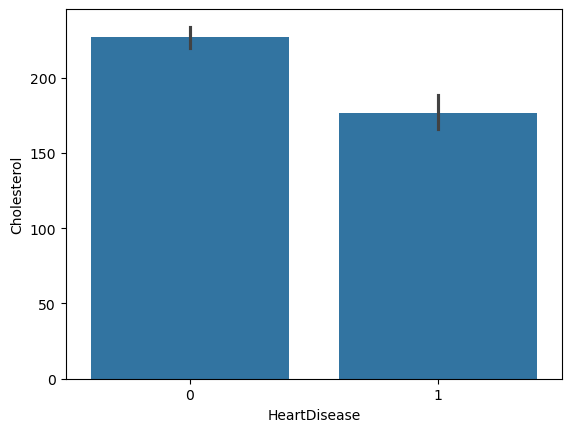

In [178]:
sns.barplot(y = "Cholesterol" , x = "HeartDisease" , data = df)

### 4. MaxHR and HeartDisease 

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

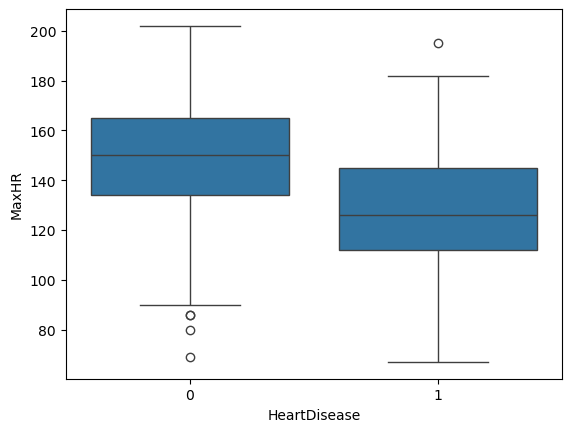

In [179]:
sns.boxplot(y = "MaxHR" , x = "HeartDisease" , data = df)

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

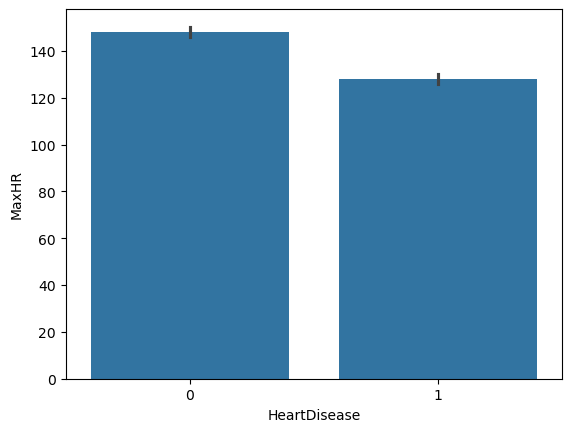

In [180]:
sns.barplot(y = "MaxHR" , x = "HeartDisease" , data = df)

### 5. Oldpeak and HeartDisease 

<Axes: xlabel='HeartDisease', ylabel='Oldpeak'>

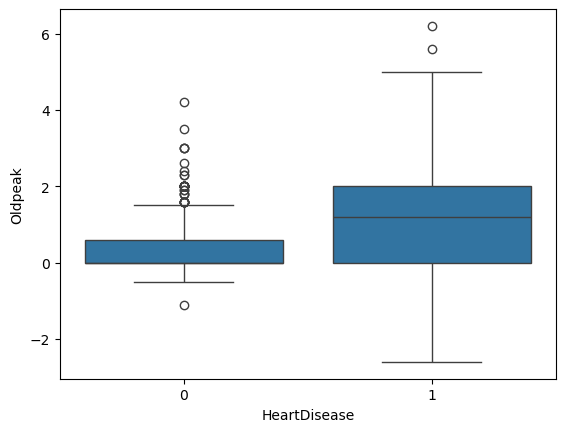

In [181]:
sns.boxplot(y = "Oldpeak" , x = "HeartDisease" , data = df)

<Axes: xlabel='HeartDisease', ylabel='Oldpeak'>

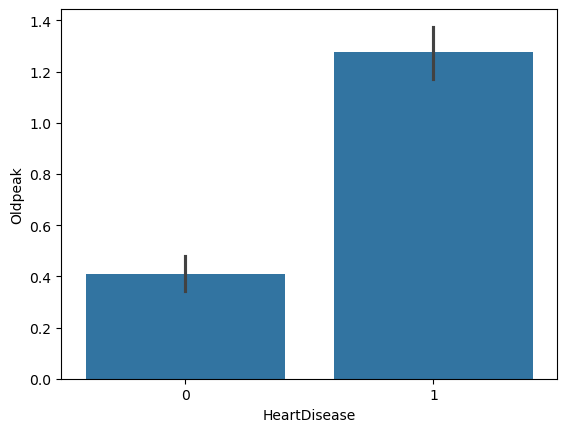

In [182]:
sns.barplot(y = "Oldpeak" , x = "HeartDisease" , data = df)